In [1]:
# ============================================================
# Modeling Part 3 - Out-of-Sample Prediction and Combined Signal
# ============================================================
#
# Goal:
# 1. Load the clean simple earnings straddle dataset
# 2. Create features available before earnings
# 3. Build a simple hand-made combined score
# 4. Build out-of-sample regression models
# 5. Rank earnings events by predicted edge
# 6. Check whether predicted-good straddles actually had better realized edge
#
# Main target:
# simple_straddle_edge_open = realized move - implied move
#
# Positive edge:
#     stock moved more than options implied
#     straddle was cheap
#
# Negative edge:
#     stock moved less than options implied
#     straddle was expensive

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

con = duckdb.connect()

PROCESSED_DIR = r"data\processed"

# Inputs from Modeling Part 1
loose_file = os.path.join(PROCESSED_DIR, "earnings_model_simple_clean_loose.parquet")
strict_file = os.path.join(PROCESSED_DIR, "earnings_model_simple_clean_strict.parquet")

# Outputs from this notebook
oos_predictions_file = os.path.join(PROCESSED_DIR, "modeling_part3_oos_predictions.parquet")
oos_quintile_results_file = os.path.join(PROCESSED_DIR, "modeling_part3_oos_quintile_results.parquet")
hand_score_results_file = os.path.join(PROCESSED_DIR, "modeling_part3_hand_score_results.parquet")

print("Loose input file:")
print(loose_file)

print("\nStrict input file:")
print(strict_file)

print("\nOutput files:")
print(oos_predictions_file)
print(oos_quintile_results_file)
print(hand_score_results_file)

Loose input file:
data\processed\earnings_model_simple_clean_loose.parquet

Strict input file:
data\processed\earnings_model_simple_clean_strict.parquet

Output files:
data\processed\modeling_part3_oos_predictions.parquet
data\processed\modeling_part3_oos_quintile_results.parquet
data\processed\modeling_part3_hand_score_results.parquet


In [2]:
# Helper function to display SQL query output neatly

def show(title, query, n=30):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    
    df = con.execute(query).df()
    
    if len(df) > n:
        print(df.head(n).to_string(index=False))
        print(f"\n[showing first {n} rows out of {len(df)}]")
    else:
        print(df.to_string(index=False))
    
    return df


# Helper function for making quintile tables in pandas

def make_quintile_table(
    df,
    score_col,
    target_col="simple_straddle_edge_open",
    n_quintiles=5,
    ascending=True
):
    """
    Splits data into quintiles based on score_col and summarizes actual target.

    ascending=True:
        Q1 = lowest score
        Q5 = highest score

    For predicted_edge:
        Q5 should ideally have better actual edge than Q1.
    """
    temp = df.copy()
    temp = temp.dropna(subset=[score_col, target_col]).copy()
    
    # qcut can fail if there are too many duplicate values.
    # rank(method='first') helps make unique ordering.
    temp["quintile"] = pd.qcut(
        temp[score_col].rank(method="first", ascending=ascending),
        q=n_quintiles,
        labels=False
    ) + 1
    
    out = (
        temp
        .groupby("quintile")
        .agg(
            n_events=(target_col, "size"),
            n_tickers=("tic", "nunique"),
            avg_score=(score_col, "mean"),
            avg_actual_edge=(target_col, "mean"),
            median_actual_edge=(target_col, "median"),
            pct_positive_edge=(target_col, lambda x: np.mean(x > 0)),
            avg_implied_move=("implied_move_simple", "mean"),
            avg_realized_move=("realized_move_open_to_prevclose", "mean")
        )
        .reset_index()
    )
    
    return out


# Helper function for plotting quintile results

def plot_quintile_table(qdf, title):
    plt.figure(figsize=(8, 5))
    plt.bar(qdf["quintile"], qdf["avg_actual_edge"])
    plt.axhline(0, linewidth=1)
    plt.xlabel("Quintile")
    plt.ylabel("Average Actual Edge")
    plt.title(title)
    plt.show()

In [3]:
# Check that files from Modeling Part 1 exist

for file in [loose_file, strict_file]:
    if not os.path.exists(file):
        raise FileNotFoundError(
            f"Could not find {file}. Run Modeling Part 1 first."
        )

print("Both input files found.")

Both input files found.


In [4]:
# Load datasets into DuckDB
#
# loose:
#     bigger dataset, used as main modeling sample
#
# strict:
#     cleaner liquidity dataset, used later as robustness check

con.execute(f"""
CREATE OR REPLACE TEMP TABLE loose AS
SELECT *
FROM read_parquet('{loose_file}')
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE strict AS
SELECT *
FROM read_parquet('{strict_file}')
""")

show(
    "Input dataset counts",
    """
    SELECT 
        'loose' AS dataset,
        COUNT(*) AS n_rows,
        COUNT(DISTINCT tic) AS n_tickers,
        MIN(rdq) AS start_date,
        MAX(rdq) AS end_date
    FROM loose

    UNION ALL

    SELECT 
        'strict' AS dataset,
        COUNT(*) AS n_rows,
        COUNT(DISTINCT tic) AS n_tickers,
        MIN(rdq) AS start_date,
        MAX(rdq) AS end_date
    FROM strict
    """
)


Input dataset counts
dataset  n_rows  n_tickers start_date   end_date
  loose    9022        474 2018-02-08 2024-12-20
 strict    7412        457 2018-02-08 2024-12-20


,dataset,n_rows,n_tickers,start_date,end_date
0,loose,9022,474,2018-02-08,2024-12-20
1,strict,7412,457,2018-02-08,2024-12-20


In [5]:
# Create modeling features.
#
# All of these are known before earnings:
#
# implied_move_simple:
#     option market's implied earnings move
#
# total_spread_pct:
#     average bid-ask spread percentage of call and put
#
# total_open_interest:
#     call open interest + put open interest
#
# total_volume:
#     call volume + put volume
#
# log_total_open_interest:
#     log-scaled open interest
#
# log_total_volume:
#     log-scaled volume
#
# log_stock_price:
#     log-scaled stock price
#
# earnings_month:
#     month of earnings announcement
#
# Target:
#     simple_straddle_edge_open

con.execute("""
CREATE OR REPLACE TEMP TABLE loose_features AS
SELECT
    *,
    
    (after_call_spread_pct + after_put_spread_pct) / 2.0 AS total_spread_pct,
    
    COALESCE(after_call_oi, 0) + COALESCE(after_put_oi, 0) AS total_open_interest,
    
    COALESCE(after_call_vol, 0) + COALESCE(after_put_vol, 0) AS total_volume,
    
    LN(1 + COALESCE(after_call_oi, 0) + COALESCE(after_put_oi, 0)) AS log_total_open_interest,
    
    LN(1 + COALESCE(after_call_vol, 0) + COALESCE(after_put_vol, 0)) AS log_total_volume,
    
    LN(om_close) AS log_stock_price

FROM loose
WHERE simple_straddle_edge_open IS NOT NULL
  AND implied_move_simple IS NOT NULL
  AND after_call_spread_pct IS NOT NULL
  AND after_put_spread_pct IS NOT NULL
  AND om_close IS NOT NULL
  AND om_close > 0
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE strict_features AS
SELECT
    *,
    
    (after_call_spread_pct + after_put_spread_pct) / 2.0 AS total_spread_pct,
    
    COALESCE(after_call_oi, 0) + COALESCE(after_put_oi, 0) AS total_open_interest,
    
    COALESCE(after_call_vol, 0) + COALESCE(after_put_vol, 0) AS total_volume,
    
    LN(1 + COALESCE(after_call_oi, 0) + COALESCE(after_put_oi, 0)) AS log_total_open_interest,
    
    LN(1 + COALESCE(after_call_vol, 0) + COALESCE(after_put_vol, 0)) AS log_total_volume,
    
    LN(om_close) AS log_stock_price

FROM strict
WHERE simple_straddle_edge_open IS NOT NULL
  AND implied_move_simple IS NOT NULL
  AND after_call_spread_pct IS NOT NULL
  AND after_put_spread_pct IS NOT NULL
  AND om_close IS NOT NULL
  AND om_close > 0
""")

show(
    "Feature dataset counts",
    """
    SELECT 'loose_features' AS dataset, COUNT(*) AS n_rows FROM loose_features
    UNION ALL
    SELECT 'strict_features' AS dataset, COUNT(*) AS n_rows FROM strict_features
    """
)

show(
    "Sample feature rows",
    """
    SELECT
        tic,
        rdq,
        earnings_year,
        implied_move_simple,
        total_spread_pct,
        log_total_open_interest,
        log_total_volume,
        log_stock_price,
        earnings_month,
        simple_straddle_edge_open
    FROM loose_features
    ORDER BY rdq, tic
    LIMIT 20
    """
)


Feature dataset counts
        dataset  n_rows
 loose_features    9022
strict_features    7412

Sample feature rows
 tic        rdq  earnings_year  implied_move_simple  total_spread_pct  log_total_open_interest  log_total_volume  log_stock_price  earnings_month  simple_straddle_edge_open
NVDA 2018-02-08           2018             0.082496          0.029434                 8.377471          8.544030         5.432848               2                  -0.041193
   A 2018-02-14           2018             0.038118          0.128590                 7.398786          4.418841         4.224495               2                   0.058458
AMAT 2018-02-14           2018             0.057316          0.035222                 6.679599          6.602588         3.902982               2                  -0.004642
CSCO 2018-02-14           2018             0.049600          0.025347                 9.790095          8.634443         3.719166               2                   0.043415
NTAP 2018-02-14   

,tic,rdq,earnings_year,implied_move_simple,total_spread_pct,log_total_open_interest,log_total_volume,log_stock_price,earnings_month,simple_straddle_edge_open
0,NVDA,2018-02-08,2018,0.082496,0.029434,8.377471,8.544030,5.432848,2,-0.041193
1,A,2018-02-14,2018,0.038118,0.128590,7.398786,4.418841,4.224495,2,0.058458
2,AMAT,2018-02-14,2018,0.057316,0.035222,6.679599,6.602588,3.902982,2,-0.004642
3,CSCO,2018-02-14,2018,0.049600,0.025347,9.790095,8.634443,3.719166,2,0.043415
4,NTAP,2018-02-14,2018,0.077034,0.037560,4.983607,2.995732,4.073121,2,-0.006044
5,DE,2018-02-16,2018,0.054253,0.098527,6.638568,4.897840,5.116855,2,-0.040885
6,HD,2018-02-20,2018,0.036102,0.059043,7.950855,7.757906,5.230948,2,-0.034818
7,MDT,2018-02-20,2018,0.041592,0.020263,4.204693,7.807510,4.422569,2,-0.019025
8,WMT,2018-02-20,2018,0.052491,0.043379,7.826443,8.244071,4.651863,2,0.039798
9,HPE,2018-02-22,2018,0.060308,0.200709,6.230481,4.912655,2.788093,2,0.048000


In [6]:
# Check the features before modeling.
#
# This tells us whether the feature values look reasonable.

show(
    "Feature summary: loose",
    """
    SELECT
        COUNT(*) AS n_events,

        AVG(implied_move_simple) AS avg_implied_move,
        APPROX_QUANTILE(implied_move_simple, 0.50) AS median_implied_move,

        AVG(total_spread_pct) AS avg_total_spread_pct,
        APPROX_QUANTILE(total_spread_pct, 0.50) AS median_total_spread_pct,

        AVG(log_total_open_interest) AS avg_log_total_open_interest,
        APPROX_QUANTILE(log_total_open_interest, 0.50) AS median_log_total_open_interest,

        AVG(log_total_volume) AS avg_log_total_volume,
        APPROX_QUANTILE(log_total_volume, 0.50) AS median_log_total_volume,

        AVG(log_stock_price) AS avg_log_stock_price,
        APPROX_QUANTILE(log_stock_price, 0.50) AS median_log_stock_price,

        AVG(simple_straddle_edge_open) AS avg_edge
    FROM loose_features
    """
)


Feature summary: loose
 n_events  avg_implied_move  median_implied_move  avg_total_spread_pct  median_total_spread_pct  avg_log_total_open_interest  median_log_total_open_interest  avg_log_total_volume  median_log_total_volume  avg_log_stock_price  median_log_stock_price  avg_edge
     9022          0.057131             0.052365              0.112765                 0.077981                     6.331294                        6.348648              5.600005                 5.740467             4.644383                4.634389 -0.014408


,n_events,avg_implied_move,median_implied_move,avg_total_spread_pct,median_total_spread_pct,avg_log_total_open_interest,median_log_total_open_interest,avg_log_total_volume,median_log_total_volume,avg_log_stock_price,median_log_stock_price,avg_edge
0,9022,0.057131,0.052365,0.112765,0.077981,6.331294,6.348648,5.600005,5.740467,4.644383,4.634389,-0.014408


In [7]:
# Load the feature table into pandas for modeling with scikit-learn.

df_loose = con.execute("""
SELECT *
FROM loose_features
ORDER BY rdq, tic
""").df()

df_strict = con.execute("""
SELECT *
FROM strict_features
ORDER BY rdq, tic
""").df()

print("Loose shape:", df_loose.shape)
print("Strict shape:", df_strict.shape)

df_loose.head()

Loose shape: (9022, 48)
Strict shape: (7412, 48)


,gvkey,tic,permno,secid,rdq,prev_date,after_exdate,om_close,strike,strike_price,...,after_call_spread_pct,after_put_spread_pct,earnings_year,earnings_month,total_spread_pct,total_open_interest,total_volume,log_total_open_interest,log_total_volume,log_stock_price
0,117768,NVDA,86580,108321,2018-02-08,2018-02-07,2018-02-09,228.80,230.0,230000,...,0.038356,0.020513,2018,2,0.029434,4347,5135,8.377471,8.544030,5.432848
1,126554,A,87432,101149,2018-02-14,2018-02-13,2018-02-16,68.34,67.5,67500,...,0.075362,0.181818,2018,2,0.128590,1633,82,7.398786,4.418841,4.224495
2,001704,AMAT,14702,101610,2018-02-14,2018-02-13,2018-02-16,49.55,49.5,49500,...,0.034602,0.035842,2018,2,0.035222,795,736,6.679599,6.602588,3.902982
3,020779,CSCO,76076,103042,2018-02-14,2018-02-13,2018-02-16,41.23,41.0,41000,...,0.017544,0.033149,2018,2,0.025347,17855,5621,9.790095,8.634443,3.719166
4,061591,NTAP,82598,108055,2018-02-14,2018-02-13,2018-02-16,58.74,58.5,58500,...,0.037736,0.037383,2018,2,0.037560,145,19,4.983607,2.995732,4.073121


In [8]:
# Before using regression, create a simple hand-built score.
#
# From Modeling Part 2, we learned:
#
# high implied move    -> worse edge
# high spread          -> worse edge
# high volume          -> better edge
# higher stock price   -> slightly better edge
#
# So an "overpriced score" can be:
#
# high implied move
# + high spread
# - high volume
# - high stock price
#
# Higher score = more likely overpriced / worse for buying straddle.
#
# To combine variables on different scales, we first convert each feature
# into a percentile rank between 0 and 1.

def add_percentile_ranks(df):
    df = df.copy()
    
    df["rank_implied_move"] = df["implied_move_simple"].rank(pct=True)
    df["rank_spread"] = df["total_spread_pct"].rank(pct=True)
    df["rank_volume"] = df["log_total_volume"].rank(pct=True)
    df["rank_stock_price"] = df["log_stock_price"].rank(pct=True)
    df["rank_open_interest"] = df["log_total_open_interest"].rank(pct=True)
    
    return df

df_loose = add_percentile_ranks(df_loose)
df_strict = add_percentile_ranks(df_strict)

df_loose[
    [
        "tic",
        "rdq",
        "rank_implied_move",
        "rank_spread",
        "rank_volume",
        "rank_stock_price",
        "rank_open_interest"
    ]
].head()

,tic,rdq,rank_implied_move,rank_spread,rank_volume,rank_stock_price,rank_open_interest
0,NVDA,2018-02-08,0.877743,0.147307,0.933330,0.812292,0.899911
1,A,2018-02-14,0.199623,0.704722,0.272223,0.323099,0.738750
2,AMAT,2018-02-14,0.594658,0.197961,0.676402,0.203059,0.580082
3,CSCO,2018-02-14,0.444026,0.111727,0.938705,0.147196,0.981046
4,NTAP,2018-02-14,0.837065,0.219131,0.114221,0.265961,0.207437


In [9]:
# Create the hand-built score.
#
# Higher overpriced_score means:
#     more likely expensive / worse edge
#
# Since edge = realized - implied:
#     expensive straddles should have lower edge.
#
# So if this score works, high score quintile should have more negative actual edge.

df_loose["overpriced_score"] = (
    df_loose["rank_implied_move"]
    + df_loose["rank_spread"]
    - df_loose["rank_volume"]
    - df_loose["rank_stock_price"]
)

df_strict["overpriced_score"] = (
    df_strict["rank_implied_move"]
    + df_strict["rank_spread"]
    - df_strict["rank_volume"]
    - df_strict["rank_stock_price"]
)

# Also create the opposite:
# Higher predicted_good_score means more likely better for buying straddles.
df_loose["predicted_good_score"] = -df_loose["overpriced_score"]
df_strict["predicted_good_score"] = -df_strict["overpriced_score"]

print("Loose score summary:")
display(df_loose[["overpriced_score", "predicted_good_score"]].describe())

print("Strict score summary:")
display(df_strict[["overpriced_score", "predicted_good_score"]].describe())

Loose score summary:


,overpriced_score,predicted_good_score
count,9022.000000,9022.000000
mean,0.000000,0.000000
std,0.632108,0.632108
min,-1.730215,-1.812237
25%,-0.443513,-0.454417
50%,0.015019,-0.015019
75%,0.454417,0.443513
max,1.812237,1.730215


Strict score summary:


,overpriced_score,predicted_good_score
count,7.412000e+03,7.412000e+03
mean,-1.342094e-17,1.342094e-17
std,6.346658e-01,6.346658e-01
min,-1.731516e+00,-1.845723e+00
25%,-4.520710e-01,-4.584120e-01
50%,1.848354e-02,-1.848354e-02
75%,4.584120e-01,4.520710e-01
max,1.845723e+00,1.731516e+00


Loose: quintiles by hand-built overpriced score


,quintile,n_events,n_tickers,avg_score,avg_actual_edge,median_actual_edge,pct_positive_edge,avg_implied_move,avg_realized_move
0,1,1805,192,-0.903665,-0.006081,-0.011089,0.344044,0.043735,0.037655
1,2,1804,314,-0.344905,-0.009412,-0.013597,0.321508,0.051161,0.041748
2,3,1804,362,0.014859,-0.012456,-0.016829,0.299889,0.058276,0.045821
3,4,1804,383,0.363533,-0.018278,-0.024102,0.243902,0.061673,0.043394
4,5,1805,331,0.870196,-0.025812,-0.031265,0.198892,0.070811,0.044999


Strict: quintiles by hand-built overpriced score


,quintile,n_events,n_tickers,avg_score,avg_actual_edge,median_actual_edge,pct_positive_edge,avg_implied_move,avg_realized_move
0,1,1483,169,-0.907092,-0.006448,-0.011365,0.335806,0.043911,0.037463
1,2,1482,279,-0.350921,-0.007207,-0.011494,0.341430,0.050934,0.043727
2,3,1482,333,0.018463,-0.012863,-0.016700,0.297571,0.057651,0.044788
3,4,1482,345,0.363284,-0.016617,-0.022216,0.274629,0.062089,0.045471
4,5,1483,308,0.876286,-0.024811,-0.029886,0.216453,0.071823,0.047011


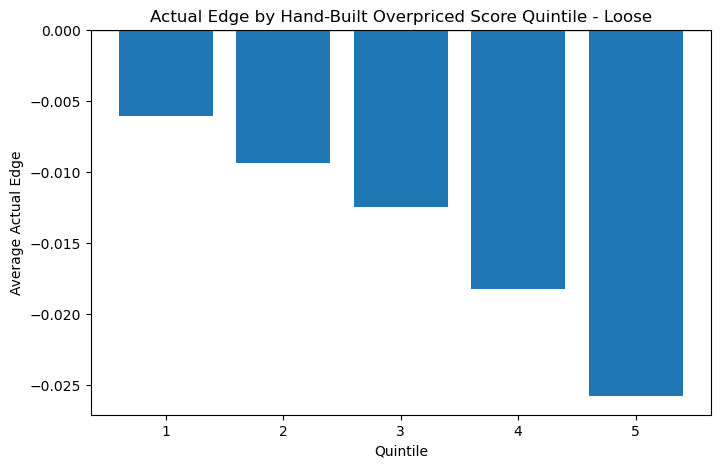

In [10]:
# Test the hand-built score.
#
# For overpriced_score:
#     Q1 = least overpriced
#     Q5 = most overpriced
#
# If the score works:
#     Q5 should have more negative actual edge than Q1.

hand_loose_overpriced = make_quintile_table(
    df_loose,
    score_col="overpriced_score",
    target_col="simple_straddle_edge_open",
    ascending=True
)

hand_strict_overpriced = make_quintile_table(
    df_strict,
    score_col="overpriced_score",
    target_col="simple_straddle_edge_open",
    ascending=True
)

print("Loose: quintiles by hand-built overpriced score")
display(hand_loose_overpriced)

print("Strict: quintiles by hand-built overpriced score")
display(hand_strict_overpriced)

plot_quintile_table(
    hand_loose_overpriced,
    "Actual Edge by Hand-Built Overpriced Score Quintile - Loose"
)

In [11]:
# Compare Q5 and Q1 for the hand-built overpriced score.
#
# For overpriced_score:
#     Q5 - Q1 should be negative if high score means worse edge.

def q5_minus_q1(qdf):
    q1 = qdf.loc[qdf["quintile"] == 1, "avg_actual_edge"].iloc[0]
    q5 = qdf.loc[qdf["quintile"] == 5, "avg_actual_edge"].iloc[0]
    return q1, q5, q5 - q1

loose_q1, loose_q5, loose_spread = q5_minus_q1(hand_loose_overpriced)
strict_q1, strict_q5, strict_spread = q5_minus_q1(hand_strict_overpriced)

hand_score_summary = pd.DataFrame({
    "dataset": ["loose", "strict"],
    "score": ["overpriced_score", "overpriced_score"],
    "q1_edge": [loose_q1, strict_q1],
    "q5_edge": [loose_q5, strict_q5],
    "q5_minus_q1_edge": [loose_spread, strict_spread]
})

display(hand_score_summary)

,dataset,score,q1_edge,q5_edge,q5_minus_q1_edge
0,loose,overpriced_score,-0.006081,-0.025812,-0.019731
1,strict,overpriced_score,-0.006448,-0.024811,-0.018364


In [12]:
# Save hand-built score quintile results.

hand_loose_overpriced["dataset"] = "loose"
hand_strict_overpriced["dataset"] = "strict"

hand_results = pd.concat(
    [hand_loose_overpriced, hand_strict_overpriced],
    ignore_index=True
)

if os.path.exists(hand_score_results_file):
    os.remove(hand_score_results_file)

con.register("hand_results_df", hand_results)

con.execute(f"""
COPY hand_results_df
TO '{hand_score_results_file}'
(FORMAT PARQUET)
""")

print("Saved hand-built score results to:")
print(hand_score_results_file)

Saved hand-built score results to:
data\processed\modeling_part3_hand_score_results.parquet


In [13]:
# Now we move from hand-built score to a basic regression model.
#
# The model will learn a relationship:
#
# features available before earnings -> future straddle edge
#
# Target:
#     simple_straddle_edge_open
#
# Features:
#     all available before earnings
#
# Important:
#     Do NOT include realized_move_open_to_prevclose as a feature.
#     That is only known after earnings and would be cheating.

target_col = "simple_straddle_edge_open"

feature_cols = [
    "implied_move_simple",
    "total_spread_pct",
    "log_total_open_interest",
    "log_total_volume",
    "log_stock_price",
    "earnings_month"
]

print("Target:")
print(target_col)

print("\nFeatures:")
for col in feature_cols:
    print("-", col)

Target:
simple_straddle_edge_open

Features:
- implied_move_simple
- total_spread_pct
- log_total_open_interest
- log_total_volume
- log_stock_price
- earnings_month


In [24]:
# Keep only rows where target and features are non-missing.
#
# We also keep realized_move_open_to_prevclose because later quintile tables
# summarize both:
#     actual edge
#     realized move
#     implied move
#
# realized_move_open_to_prevclose is NOT used as a model input.
# It is only kept for reporting outputs.

model_df = df_loose[
    [
        "tic",
        "rdq",
        "earnings_year",
        "realized_move_open_to_prevclose",  # keep for reporting
        target_col
    ] + feature_cols
].dropna().copy()

model_df = model_df.sort_values(["rdq", "tic"]).reset_index(drop=True)

print("Modeling dataset shape:", model_df.shape)

display(model_df.head())
display(model_df.tail())

Modeling dataset shape: (9022, 11)


,tic,rdq,earnings_year,realized_move_open_to_prevclose,simple_straddle_edge_open,implied_move_simple,total_spread_pct,log_total_open_interest,log_total_volume,log_stock_price,earnings_month
0,NVDA,2018-02-08,2018,0.041302,-0.041193,0.082496,0.029434,8.377471,8.544030,5.432848,2
1,A,2018-02-14,2018,0.096576,0.058458,0.038118,0.128590,7.398786,4.418841,4.224495,2
2,AMAT,2018-02-14,2018,0.052674,-0.004642,0.057316,0.035222,6.679599,6.602588,3.902982,2
3,CSCO,2018-02-14,2018,0.093015,0.043415,0.049600,0.025347,9.790095,8.634443,3.719166,2
4,NTAP,2018-02-14,2018,0.070991,-0.006044,0.077034,0.037560,4.983607,2.995732,4.073121,2


,tic,rdq,earnings_year,realized_move_open_to_prevclose,simple_straddle_edge_open,implied_move_simple,total_spread_pct,log_total_open_interest,log_total_volume,log_stock_price,earnings_month
9017,FDX,2024-12-19,2024,0.076292,-0.030056,0.106348,0.092085,5.484797,3.637586,5.610058,12
9018,LW,2024-12-19,2024,0.201867,0.116211,0.085656,0.174380,7.539027,5.123964,4.359525,12
9019,NKE,2024-12-19,2024,0.012224,-0.071326,0.083550,0.023507,8.241440,5.777652,4.342506,12
9020,PAYX,2024-12-19,2024,0.005300,-0.044568,0.049868,0.082222,6.666957,6.293419,4.911625,12
9021,CCL,2024-12-20,2024,0.053217,-0.038721,0.091938,0.047646,7.791110,7.629976,3.226050,12


In [25]:
# Expanding-window testing:
#
# Train on past years, test on one future year.
#
# Example:
#     train 2018-2020 -> test 2021
#     train 2018-2021 -> test 2022
#     train 2018-2022 -> test 2023
#     train 2018-2023 -> test 2024
#
# This avoids look-ahead bias.
# The model never trains on future data before predicting past data.

available_years = sorted(model_df["earnings_year"].unique())
print("Available years:", available_years)

test_years = [2021, 2022, 2023, 2024]

print("Test years:", test_years)

Available years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Test years: [2021, 2022, 2023, 2024]


In [26]:
# Run expanding-window out-of-sample linear regression.
#
# For each test year:
#     train on all years before that test year
#     predict the test year
#
# We use StandardScaler so features are standardized before regression.
#
# LinearRegression:
#     simple model that learns a weighted combination of features

from sklearn.metrics import root_mean_squared_error

all_predictions = []

for test_year in test_years:
    train = model_df[model_df["earnings_year"] < test_year].copy()
    test = model_df[model_df["earnings_year"] == test_year].copy()
    
    if len(train) == 0 or len(test) == 0:
        print(f"Skipping {test_year}: train or test empty")
        continue
    
    X_train = train[feature_cols]
    y_train = train[target_col]
    
    X_test = test[feature_cols]
    y_test = test[target_col]
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ])
    
    model.fit(X_train, y_train)
    
    test["predicted_edge_linear"] = model.predict(X_test)
    test["model_name"] = "linear_regression"
    test["test_year"] = test_year
    
    rmse = root_mean_squared_error(y_test, test["predicted_edge_linear"])
    mae = mean_absolute_error(y_test, test["predicted_edge_linear"])
    r2 = r2_score(y_test, test["predicted_edge_linear"])
    
    print(f"\nTest year: {test_year}")
    print(f"Train rows: {len(train):,}")
    print(f"Test rows:  {len(test):,}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE:  {mae:.6f}")
    print(f"R2:   {r2:.6f}")
    
    all_predictions.append(test)

linear_oos = pd.concat(all_predictions, ignore_index=True)

print("\nCombined linear OOS predictions shape:", linear_oos.shape)
display(linear_oos.head())


Test year: 2021
Train rows: 3,506
Test rows:  1,253
RMSE: 0.031651
MAE:  0.022726
R2:   0.058791

Test year: 2022
Train rows: 4,759
Test rows:  1,308
RMSE: 0.041021
MAE:  0.029320
R2:   0.131884

Test year: 2023
Train rows: 6,067
Test rows:  1,429
RMSE: 0.041039
MAE:  0.028101
R2:   -0.015329

Test year: 2024
Train rows: 7,496
Test rows:  1,526
RMSE: 0.044051
MAE:  0.029849
R2:   0.023295

Combined linear OOS predictions shape: (5516, 14)


,tic,rdq,earnings_year,realized_move_open_to_prevclose,simple_straddle_edge_open,implied_move_simple,total_spread_pct,log_total_open_interest,log_total_volume,log_stock_price,earnings_month,predicted_edge_linear,model_name,test_year
0,LW,2021-01-07,2021,0.017356,-0.049197,0.066554,0.154262,7.021084,4.634729,4.338989,1,-0.024945,linear_regression,2021
1,MU,2021-01-07,2021,0.070419,0.003437,0.066982,0.017384,8.165648,8.351847,4.345233,1,-0.016863,linear_regression,2021
2,STZ,2021-01-07,2021,0.028697,-0.016673,0.045369,0.090650,4.787492,5.010635,5.410395,1,-0.009796,linear_regression,2021
3,CCL,2021-01-11,2021,0.020518,-0.066683,0.087201,0.017033,8.828055,8.609408,3.018960,1,-0.025476,linear_regression,2021
4,BLK,2021-01-14,2021,0.048182,0.022789,0.025393,0.112700,5.634790,6.424869,6.658973,1,-0.001416,linear_regression,2021


In [27]:
# Ridge regression is similar to linear regression,
# but it shrinks coefficients to reduce overfitting.
#
# This can be more stable than plain linear regression.

all_predictions = []

for test_year in test_years:
    train = model_df[model_df["earnings_year"] < test_year].copy()
    test = model_df[model_df["earnings_year"] == test_year].copy()
    
    if len(train) == 0 or len(test) == 0:
        print(f"Skipping {test_year}: train or test empty")
        continue
    
    X_train = train[feature_cols]
    y_train = train[target_col]
    
    X_test = test[feature_cols]
    y_test = test[target_col]
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0))
    ])
    
    model.fit(X_train, y_train)
    
    test["predicted_edge_ridge"] = model.predict(X_test)
    test["model_name"] = "ridge_regression"
    test["test_year"] = test_year
    
    rmse = root_mean_squared_error(y_test, test["predicted_edge_ridge"])
    mae = mean_absolute_error(y_test, test["predicted_edge_ridge"])
    r2 = r2_score(y_test, test["predicted_edge_ridge"])
    
    print(f"\nTest year: {test_year}")
    print(f"Train rows: {len(train):,}")
    print(f"Test rows:  {len(test):,}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE:  {mae:.6f}")
    print(f"R2:   {r2:.6f}")
    
    all_predictions.append(test)

ridge_oos = pd.concat(all_predictions, ignore_index=True)

print("\nCombined ridge OOS predictions shape:", ridge_oos.shape)
display(ridge_oos.head())


Test year: 2021
Train rows: 3,506
Test rows:  1,253
RMSE: 0.031651
MAE:  0.022725
R2:   0.058796

Test year: 2022
Train rows: 4,759
Test rows:  1,308
RMSE: 0.041021
MAE:  0.029320
R2:   0.131875

Test year: 2023
Train rows: 6,067
Test rows:  1,429
RMSE: 0.041039
MAE:  0.028101
R2:   -0.015315

Test year: 2024
Train rows: 7,496
Test rows:  1,526
RMSE: 0.044051
MAE:  0.029849
R2:   0.023300

Combined ridge OOS predictions shape: (5516, 14)


,tic,rdq,earnings_year,realized_move_open_to_prevclose,simple_straddle_edge_open,implied_move_simple,total_spread_pct,log_total_open_interest,log_total_volume,log_stock_price,earnings_month,predicted_edge_ridge,model_name,test_year
0,LW,2021-01-07,2021,0.017356,-0.049197,0.066554,0.154262,7.021084,4.634729,4.338989,1,-0.024941,ridge_regression,2021
1,MU,2021-01-07,2021,0.070419,0.003437,0.066982,0.017384,8.165648,8.351847,4.345233,1,-0.016861,ridge_regression,2021
2,STZ,2021-01-07,2021,0.028697,-0.016673,0.045369,0.090650,4.787492,5.010635,5.410395,1,-0.009797,ridge_regression,2021
3,CCL,2021-01-11,2021,0.020518,-0.066683,0.087201,0.017033,8.828055,8.609408,3.018960,1,-0.025473,ridge_regression,2021
4,BLK,2021-01-14,2021,0.048182,0.022789,0.025393,0.112700,5.634790,6.424869,6.658973,1,-0.001418,ridge_regression,2021


In [28]:
# Combine linear and ridge predictions into one dataframe.
#
# To compare models easily, create one common column:
#     predicted_edge
#
# We keep realized_move_open_to_prevclose for reporting in quintile tables.

linear_eval = linear_oos.copy()
linear_eval["predicted_edge"] = linear_eval["predicted_edge_linear"]
linear_eval["model"] = "linear_regression"

ridge_eval = ridge_oos.copy()
ridge_eval["predicted_edge"] = ridge_eval["predicted_edge_ridge"]
ridge_eval["model"] = "ridge_regression"

common_cols = [
    "tic",
    "rdq",
    "earnings_year",
    "test_year",
    "model",
    target_col,
    "realized_move_open_to_prevclose",
    "predicted_edge"
] + feature_cols

oos_predictions = pd.concat(
    [
        linear_eval[common_cols],
        ridge_eval[common_cols]
    ],
    ignore_index=True
)

print("All OOS predictions shape:", oos_predictions.shape)
display(oos_predictions.head())

All OOS predictions shape: (11032, 14)


,tic,rdq,earnings_year,test_year,model,simple_straddle_edge_open,realized_move_open_to_prevclose,predicted_edge,implied_move_simple,total_spread_pct,log_total_open_interest,log_total_volume,log_stock_price,earnings_month
0,LW,2021-01-07,2021,2021,linear_regression,-0.049197,0.017356,-0.024945,0.066554,0.154262,7.021084,4.634729,4.338989,1
1,MU,2021-01-07,2021,2021,linear_regression,0.003437,0.070419,-0.016863,0.066982,0.017384,8.165648,8.351847,4.345233,1
2,STZ,2021-01-07,2021,2021,linear_regression,-0.016673,0.028697,-0.009796,0.045369,0.090650,4.787492,5.010635,5.410395,1
3,CCL,2021-01-11,2021,2021,linear_regression,-0.066683,0.020518,-0.025476,0.087201,0.017033,8.828055,8.609408,3.018960,1
4,BLK,2021-01-14,2021,2021,linear_regression,0.022789,0.048182,-0.001416,0.025393,0.112700,5.634790,6.424869,6.658973,1


In [29]:
# Check whether predicted edge is correlated with actual edge.
#
# If correlation is positive:
#     higher predicted edge tends to mean higher actual edge.
#
# This is what we want.

model_corr = (
    oos_predictions
    .groupby("model")
    .apply(lambda g: pd.Series({
        "n_events": len(g),
        "corr_pred_actual": g["predicted_edge"].corr(g[target_col]),
        "avg_predicted_edge": g["predicted_edge"].mean(),
        "avg_actual_edge": g[target_col].mean()
    }))
    .reset_index()
)

display(model_corr)

,model,n_events,corr_pred_actual,avg_predicted_edge,avg_actual_edge
0,linear_regression,5516.0,0.247981,-0.016464,-0.0136
1,ridge_regression,5516.0,0.247979,-0.016464,-0.0136


,quintile,n_events,n_tickers,avg_score,avg_actual_edge,median_actual_edge,pct_positive_edge,avg_implied_move,avg_realized_move,model
0,1,1104,241,-0.033277,-0.025407,-0.037477,0.248188,0.091109,0.065702,linear_regression
1,2,1103,340,-0.020659,-0.016160,-0.026149,0.258386,0.064008,0.047848,linear_regression
2,3,1103,351,-0.014923,-0.013455,-0.021880,0.274705,0.053860,0.040405,linear_regression
3,4,1103,293,-0.009805,-0.007911,-0.013995,0.319130,0.044990,0.037079,linear_regression
4,5,1103,190,-0.003642,-0.005059,-0.009858,0.353581,0.035321,0.030262,linear_regression
5,1,1104,241,-0.033273,-0.025407,-0.037477,0.248188,0.091109,0.065702,ridge_regression
6,2,1103,340,-0.020658,-0.016160,-0.026149,0.258386,0.064008,0.047848,ridge_regression
7,3,1103,351,-0.014923,-0.013475,-0.021880,0.274705,0.053879,0.040404,ridge_regression
8,4,1103,293,-0.009806,-0.007891,-0.013995,0.319130,0.044971,0.037080,ridge_regression
9,5,1103,190,-0.003645,-0.005059,-0.009858,0.353581,0.035321,0.030262,ridge_regression


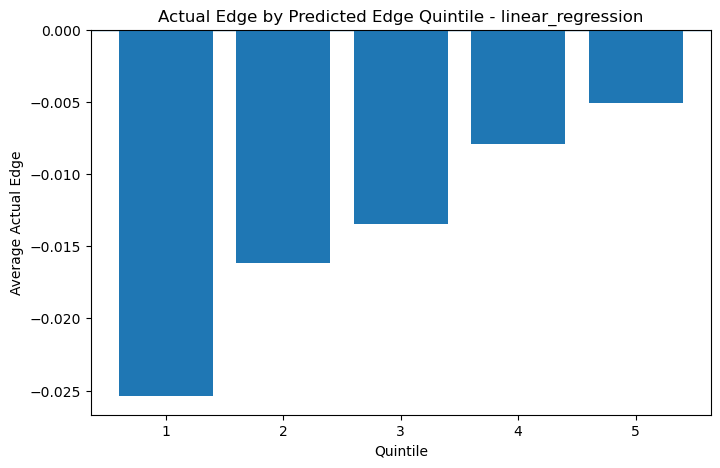

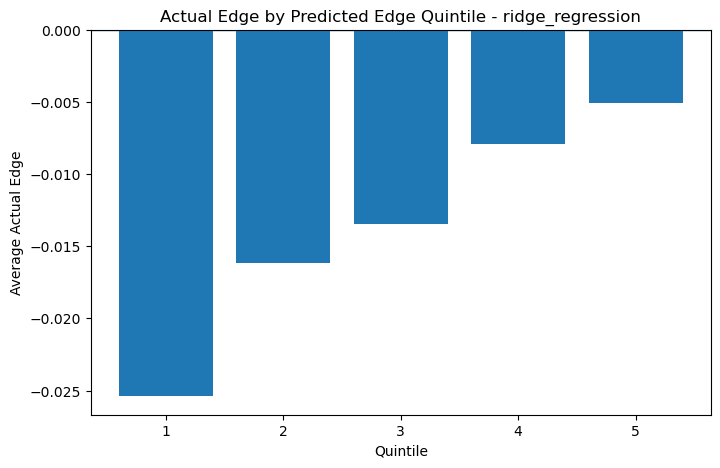

In [30]:
# Main test:
#
# Sort test-year predictions into quintiles by predicted_edge.
#
# Q1 = lowest predicted edge
# Q5 = highest predicted edge
#
# If model works:
#     Q5 actual edge should be higher than Q1 actual edge.

quintile_tables = []

for model_name in oos_predictions["model"].unique():
    temp = oos_predictions[oos_predictions["model"] == model_name].copy()
    
    qdf = make_quintile_table(
        temp,
        score_col="predicted_edge",
        target_col=target_col,
        ascending=True
    )
    
    qdf["model"] = model_name
    quintile_tables.append(qdf)

model_quintiles = pd.concat(quintile_tables, ignore_index=True)

display(model_quintiles)

# Plot each model
for model_name in model_quintiles["model"].unique():
    qdf = model_quintiles[model_quintiles["model"] == model_name]
    plot_quintile_table(
        qdf,
        f"Actual Edge by Predicted Edge Quintile - {model_name}"
    )

In [31]:
# Check model performance year by year.
#
# We want to know whether Q5 - Q1 is positive in each test year,
# or whether the result is driven by only one year.

yearly_rows = []

for model_name in oos_predictions["model"].unique():
    model_data = oos_predictions[oos_predictions["model"] == model_name].copy()
    
    for year in sorted(model_data["test_year"].unique()):
        temp = model_data[model_data["test_year"] == year].copy()
        
        if len(temp) < 50:
            continue
        
        qdf = make_quintile_table(
            temp,
            score_col="predicted_edge",
            target_col=target_col,
            ascending=True
        )
        
        q1 = qdf.loc[qdf["quintile"] == 1, "avg_actual_edge"].iloc[0]
        q5 = qdf.loc[qdf["quintile"] == 5, "avg_actual_edge"].iloc[0]
        
        yearly_rows.append({
            "model": model_name,
            "test_year": year,
            "q1_actual_edge": q1,
            "q5_actual_edge": q5,
            "q5_minus_q1_actual_edge": q5 - q1,
            "n_events": len(temp)
        })

yearly_model_results = pd.DataFrame(yearly_rows)

display(yearly_model_results)

,model,test_year,q1_actual_edge,q5_actual_edge,q5_minus_q1_actual_edge,n_events
0,linear_regression,2021,-0.028721,-0.004883,0.023838,1253
1,linear_regression,2022,-0.036556,-0.006309,0.030247,1308
2,linear_regression,2023,-0.015927,-0.003015,0.012913,1429
3,linear_regression,2024,-0.018073,-0.005132,0.012942,1526
4,ridge_regression,2021,-0.028721,-0.004883,0.023838,1253
5,ridge_regression,2022,-0.036556,-0.006309,0.030247,1308
6,ridge_regression,2023,-0.015927,-0.003015,0.012913,1429
7,ridge_regression,2024,-0.018073,-0.005132,0.012942,1526


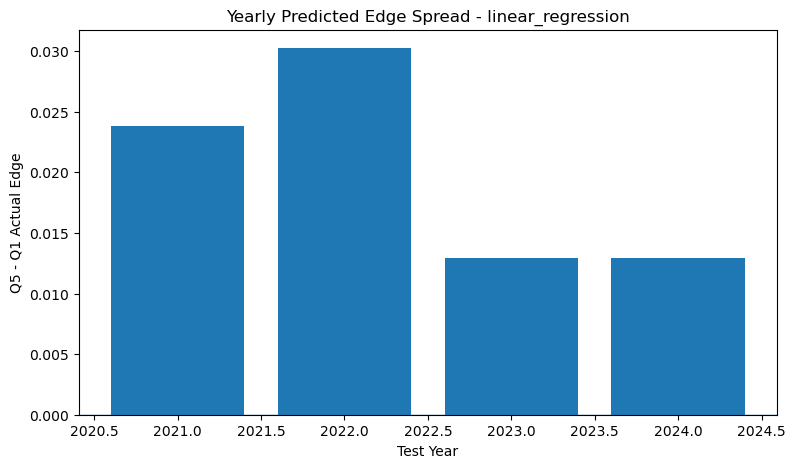

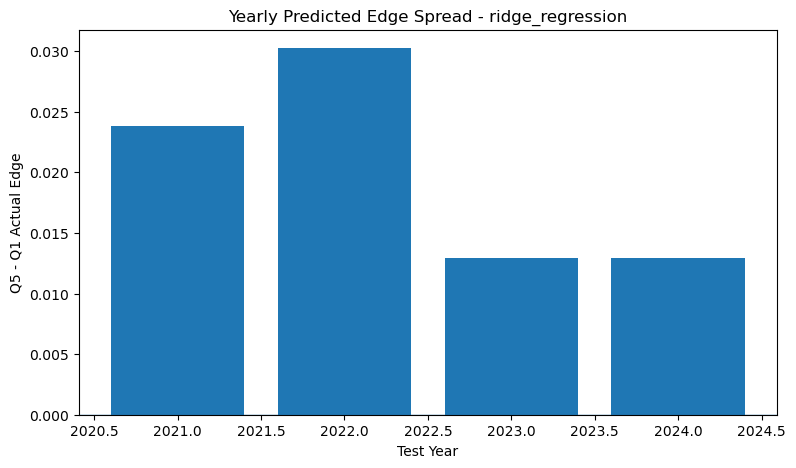

In [32]:
# Plot yearly Q5 - Q1 spread for each model.
#
# Positive bars mean:
#     highest predicted edge group had better actual edge than lowest predicted edge group.

for model_name in yearly_model_results["model"].unique():
    temp = yearly_model_results[yearly_model_results["model"] == model_name]
    
    plt.figure(figsize=(9, 5))
    plt.bar(temp["test_year"], temp["q5_minus_q1_actual_edge"])
    plt.axhline(0, linewidth=1)
    plt.xlabel("Test Year")
    plt.ylabel("Q5 - Q1 Actual Edge")
    plt.title(f"Yearly Predicted Edge Spread - {model_name}")
    plt.show()

In [33]:
# In Modeling Part 2, implied_move_simple was a strong baseline.
#
# But implied_move_simple worked in the opposite direction:
#     high implied move -> worse edge
#
# For a fair comparison, create a baseline predicted edge:
#     predicted_edge_from_implied = -implied_move_simple
#
# Higher value means lower implied move, which should be better for edge.

baseline = model_df[
    model_df["earnings_year"].isin(test_years)
].copy()

baseline["predicted_edge"] = -baseline["implied_move_simple"]
baseline["model"] = "baseline_negative_implied_move"
baseline["test_year"] = baseline["earnings_year"]

baseline_common = baseline[
    [
        "tic",
        "rdq",
        "earnings_year",
        "test_year",
        "model",
        target_col,
        "realized_move_open_to_prevclose",
        "predicted_edge"
    ] + feature_cols
].copy()

comparison_predictions = pd.concat(
    [oos_predictions, baseline_common],
    ignore_index=True
)

comparison_quintiles = []

for model_name in comparison_predictions["model"].unique():
    temp = comparison_predictions[comparison_predictions["model"] == model_name].copy()
    
    qdf = make_quintile_table(
        temp,
        score_col="predicted_edge",
        target_col=target_col,
        ascending=True
    )
    
    qdf["model"] = model_name
    comparison_quintiles.append(qdf)

comparison_quintiles = pd.concat(comparison_quintiles, ignore_index=True)

display(comparison_quintiles)

,quintile,n_events,n_tickers,avg_score,avg_actual_edge,median_actual_edge,pct_positive_edge,avg_implied_move,avg_realized_move,model
0,1,1104,241,-0.033277,-0.025407,-0.037477,0.248188,0.091109,0.065702,linear_regression
1,2,1103,340,-0.020659,-0.016160,-0.026149,0.258386,0.064008,0.047848,linear_regression
2,3,1103,351,-0.014923,-0.013455,-0.021880,0.274705,0.053860,0.040405,linear_regression
3,4,1103,293,-0.009805,-0.007911,-0.013995,0.319130,0.044990,0.037079,linear_regression
4,5,1103,190,-0.003642,-0.005059,-0.009858,0.353581,0.035321,0.030262,linear_regression
5,1,1104,241,-0.033273,-0.025407,-0.037477,0.248188,0.091109,0.065702,ridge_regression
6,2,1103,340,-0.020658,-0.016160,-0.026149,0.258386,0.064008,0.047848,ridge_regression
7,3,1103,351,-0.014923,-0.013475,-0.021880,0.274705,0.053879,0.040404,ridge_regression
8,4,1103,293,-0.009806,-0.007891,-0.013995,0.319130,0.044971,0.037080,ridge_regression
9,5,1103,190,-0.003645,-0.005059,-0.009858,0.353581,0.035321,0.030262,ridge_regression


In [34]:
# Compare Q5 - Q1 across:
#     baseline_negative_implied_move
#     linear_regression
#     ridge_regression
#
# Higher positive Q5-Q1 means better ranking.

comparison_ls_rows = []

for model_name in comparison_quintiles["model"].unique():
    qdf = comparison_quintiles[comparison_quintiles["model"] == model_name]
    
    q1 = qdf.loc[qdf["quintile"] == 1, "avg_actual_edge"].iloc[0]
    q5 = qdf.loc[qdf["quintile"] == 5, "avg_actual_edge"].iloc[0]
    
    comparison_ls_rows.append({
        "model": model_name,
        "q1_actual_edge": q1,
        "q5_actual_edge": q5,
        "q5_minus_q1_actual_edge": q5 - q1
    })

comparison_long_short = pd.DataFrame(comparison_ls_rows)
comparison_long_short = comparison_long_short.sort_values(
    "q5_minus_q1_actual_edge",
    ascending=False
)

display(comparison_long_short)

,model,q1_actual_edge,q5_actual_edge,q5_minus_q1_actual_edge
0,linear_regression,-0.025407,-0.005059,0.020347
1,ridge_regression,-0.025407,-0.005059,0.020347
2,baseline_negative_implied_move,-0.022428,-0.005016,0.017412


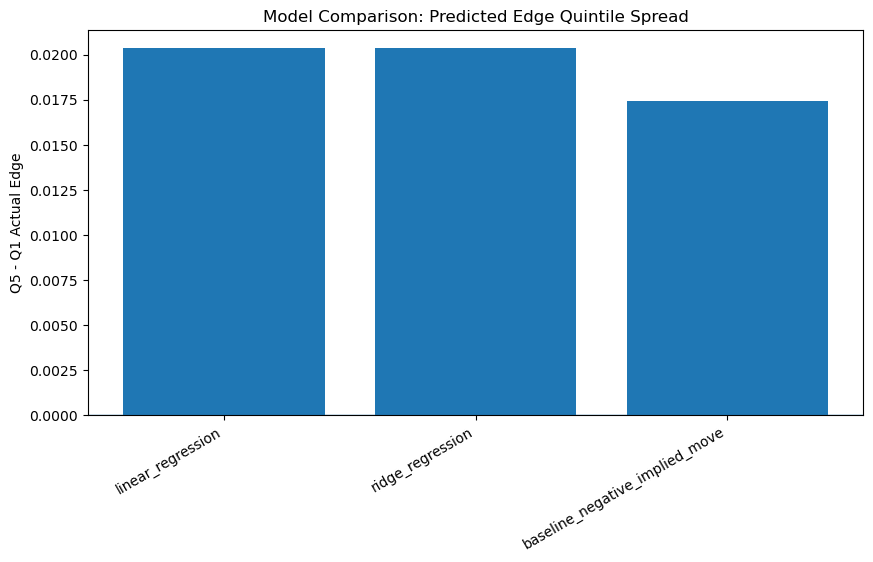

In [35]:
# Plot Q5-Q1 actual edge for each model.

plt.figure(figsize=(10, 5))
plt.bar(
    comparison_long_short["model"],
    comparison_long_short["q5_minus_q1_actual_edge"]
)
plt.axhline(0, linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Q5 - Q1 Actual Edge")
plt.title("Model Comparison: Predicted Edge Quintile Spread")
plt.show()

In [36]:
# Inspect model coefficients.
#
# This helps explain what the model learned.
#
# Since the model uses StandardScaler, coefficients are on standardized features.
# Bigger absolute coefficient = feature mattered more in the linear prediction.

coef_rows = []

for test_year in test_years:
    train = model_df[model_df["earnings_year"] < test_year].copy()
    test = model_df[model_df["earnings_year"] == test_year].copy()
    
    if len(train) == 0 or len(test) == 0:
        continue
    
    X_train = train[feature_cols]
    y_train = train[target_col]
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0))
    ])
    
    model.fit(X_train, y_train)
    
    coefs = model.named_steps["reg"].coef_
    
    for feature, coef in zip(feature_cols, coefs):
        coef_rows.append({
            "test_year": test_year,
            "feature": feature,
            "coefficient": coef
        })

coef_df = pd.DataFrame(coef_rows)

display(coef_df)

coef_summary = (
    coef_df
    .groupby("feature")
    .agg(
        avg_coefficient=("coefficient", "mean"),
        min_coefficient=("coefficient", "min"),
        max_coefficient=("coefficient", "max")
    )
    .reset_index()
    .sort_values("avg_coefficient")
)

display(coef_summary)

,test_year,feature,coefficient
0,2021,implied_move_simple,-0.010232
1,2021,total_spread_pct,-0.002394
2,2021,log_total_open_interest,-0.003350
3,2021,log_total_volume,0.004112
4,2021,log_stock_price,-0.000614
5,2021,earnings_month,0.000360
6,2022,implied_move_simple,-0.009378
7,2022,total_spread_pct,-0.001600
8,2022,log_total_open_interest,-0.003598
9,2022,log_total_volume,0.004783


,feature,avg_coefficient,min_coefficient,max_coefficient
1,implied_move_simple,-0.010130,-0.011080,-0.009378
3,log_total_open_interest,-0.003469,-0.003598,-0.003333
5,total_spread_pct,-0.001829,-0.002394,-0.001581
2,log_stock_price,-0.000014,-0.000614,0.000529
0,earnings_month,0.001077,0.000360,0.001486
4,log_total_volume,0.004578,0.004112,0.004783


In [37]:
# Save prediction and quintile results.

for f in [oos_predictions_file, oos_quintile_results_file]:
    if os.path.exists(f):
        os.remove(f)

# Save all model predictions
con.register("oos_predictions_df", oos_predictions)

con.execute(f"""
COPY oos_predictions_df
TO '{oos_predictions_file}'
(FORMAT PARQUET)
""")

# Save comparison quintiles
con.register("comparison_quintiles_df", comparison_quintiles)

con.execute(f"""
COPY comparison_quintiles_df
TO '{oos_quintile_results_file}'
(FORMAT PARQUET)
""")

print("Saved OOS predictions to:")
print(oos_predictions_file)

print("\nSaved OOS quintile results to:")
print(oos_quintile_results_file)

Saved OOS predictions to:
data\processed\modeling_part3_oos_predictions.parquet

Saved OOS quintile results to:
data\processed\modeling_part3_oos_quintile_results.parquet


In [38]:
# Final interpretation helper.
#
# This prints the most important outputs to look at.

print("=" * 100)
print("IMPORTANT OUTPUT 1: Hand-built score")
print("=" * 100)
display(hand_score_summary)

print("""
How to read this:

For overpriced_score:
    Q1 = least overpriced according to the hand-built score
    Q5 = most overpriced according to the hand-built score

If q5_minus_q1_edge is negative:
    the score is working in the expected direction.
    high overpriced score means worse future edge.
""")

print("=" * 100)
print("IMPORTANT OUTPUT 2: Model comparison")
print("=" * 100)
display(comparison_long_short)

print("""
How to read this:

For predicted_edge models:
    Q1 = lowest predicted edge
    Q5 = highest predicted edge

If q5_minus_q1_actual_edge is positive:
    the model is ranking correctly.
    the predicted-good group had better actual edge than the predicted-bad group.

Compare:
    baseline_negative_implied_move
    linear_regression
    ridge_regression

If regression beats the baseline:
    combining variables helped.

If baseline is similar or better:
    implied move alone is already the strongest simple signal.
""")

print("=" * 100)
print("IMPORTANT OUTPUT 3: Ridge coefficient summary")
print("=" * 100)
display(coef_summary)

print("""
Coefficient interpretation:

Negative coefficient:
    higher feature value predicts worse edge.

Positive coefficient:
    higher feature value predicts better edge.

Based on Modeling Part 2, we expect:
    implied_move_simple coefficient: negative
    total_spread_pct coefficient: negative
    log_total_volume coefficient: positive
""")

IMPORTANT OUTPUT 1: Hand-built score


,dataset,score,q1_edge,q5_edge,q5_minus_q1_edge
0,loose,overpriced_score,-0.006081,-0.025812,-0.019731
1,strict,overpriced_score,-0.006448,-0.024811,-0.018364



How to read this:

For overpriced_score:
    Q1 = least overpriced according to the hand-built score
    Q5 = most overpriced according to the hand-built score

If q5_minus_q1_edge is negative:
    the score is working in the expected direction.
    high overpriced score means worse future edge.

IMPORTANT OUTPUT 2: Model comparison


,model,q1_actual_edge,q5_actual_edge,q5_minus_q1_actual_edge
0,linear_regression,-0.025407,-0.005059,0.020347
1,ridge_regression,-0.025407,-0.005059,0.020347
2,baseline_negative_implied_move,-0.022428,-0.005016,0.017412



How to read this:

For predicted_edge models:
    Q1 = lowest predicted edge
    Q5 = highest predicted edge

If q5_minus_q1_actual_edge is positive:
    the model is ranking correctly.
    the predicted-good group had better actual edge than the predicted-bad group.

Compare:
    baseline_negative_implied_move
    linear_regression
    ridge_regression

If regression beats the baseline:
    combining variables helped.

If baseline is similar or better:
    implied move alone is already the strongest simple signal.

IMPORTANT OUTPUT 3: Ridge coefficient summary


,feature,avg_coefficient,min_coefficient,max_coefficient
1,implied_move_simple,-0.010130,-0.011080,-0.009378
3,log_total_open_interest,-0.003469,-0.003598,-0.003333
5,total_spread_pct,-0.001829,-0.002394,-0.001581
2,log_stock_price,-0.000014,-0.000614,0.000529
0,earnings_month,0.001077,0.000360,0.001486
4,log_total_volume,0.004578,0.004112,0.004783



Coefficient interpretation:

Negative coefficient:
    higher feature value predicts worse edge.

Positive coefficient:
    higher feature value predicts better edge.

Based on Modeling Part 2, we expect:
    implied_move_simple coefficient: negative
    total_spread_pct coefficient: negative
    log_total_volume coefficient: positive

